Last edited: 1/30/2026, 2:35 PM CST
# Nonstationary CMIP GEV Fit Analysis

In this notebook, I compare the results of fitting a nonstationary distribution to maximum temperature anomalies over land in ERA5.

In [1]:
# import base packages for data analysis
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import xesmf as xe
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.stats import genextreme, describe

from config import DATA_ROOT
from src.utils import compute_ecdf

# import custom stuff
from ambpy.plotutils import make_figure_filename
plt.style.use('ambpy')

# set random attributes
np.random.seed(4)

save_figs = True

In [24]:
ds_max = xr.open_dataset(DATA_ROOT / 'CMIP6' / 'tas_annual_max' / 'gev' / 'tas_CMIP6_AWI-CM-1-1-MR_day_hist+ssp585_1850-2015_landonly_gev.nc', engine='netcdf4')
ds_min = xr.open_dataset(DATA_ROOT / 'CMIP6' / 'tas_annual_min' / 'gev' / 'tas_CMIP6_AWI-CM-1-1-MR_day_hist+ssp585_1850-2015_landonly_gev.nc', engine='netcdf4')

## GEV parameter maps

In [25]:
def plot_nonstat_gev_parameters(ds, anom_type, vars, suptitle=None, save_fig=True,
                                filename_args=['gev-k', 'png', 'figs']):
    """
    Plot four xarray DataArrays (shape, loc, scale, k) on a 2x2 world map grid.

    Parameters
    ----------
    shape, loc, scale, k : xr.DataArray
        2D DataArrays with coordinates (lat, lon)
    titles : list or tuple of str, optional
        Custom titles for the subplots. Defaults to ['Shape', 'Location', 'Scale', 'k'].
    save_fig : bool, optional
        If True, saves the figure to `fname`.
    fname : str, optional
        Output filename if save_fig=True.
    """

    # Set up the 2x2 grid
    fig, axes = plt.subplot_mosaic(
        [
            ['A', 'B'],
            ['C', 'D'],
            ['E', 'F']
        ],
        figsize=(14, 14),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    # adjust layout to reduce whitespace 

    das = [ds[f'loc_{anom_type}'],
           ds[f'loc_t_{anom_type}'] / len(ds.year.values) * 10.,  # convert to per decade 
           ds[f'scale_{anom_type}'],
           ds[f'scale_t_{anom_type}'] / len(ds.year.values) * 10.,  # convert to per decade 
           ds[f'shape_{anom_type}'],
           ds[f'shape_t_{anom_type}'] / len(ds.year.values) * 10.  # convert to per decade
    ]

    for it, da, var in zip(axes.items(), das, vars):
        lab, ax = it
        # Add map features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
        ax.add_feature(cfeature.OCEAN, facecolor="white")

        # Plot the parameter
        im = da.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap="viridis",
            add_colorbar=False,
            vmin=np.nanpercentile(da.values, 5),
            vmax=np.nanpercentile(da.values, 95)
        )

        # Add an aligned colorbar on the right of each plot
        cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
        cbar.set_label(var)

    # add labels
    for label, ax in axes.items():
        ax.text(0.02, 1.05, f'{label}', 
                transform=ax.transAxes,
                fontsize=14, fontweight='bold',
                va='bottom', ha='right')
        ax.set_title('')

    if suptitle is not None:
        fig.suptitle(suptitle)

    fig.subplots_adjust(left=0.05, right=0.85, top=0.55, bottom=0.02)

    if save_figs:
        plt.savefig(make_figure_filename(*filename_args), dpi=300, bbox_inches="tight")
        print('Figure saved!')
    plt.show()

Figure saved!


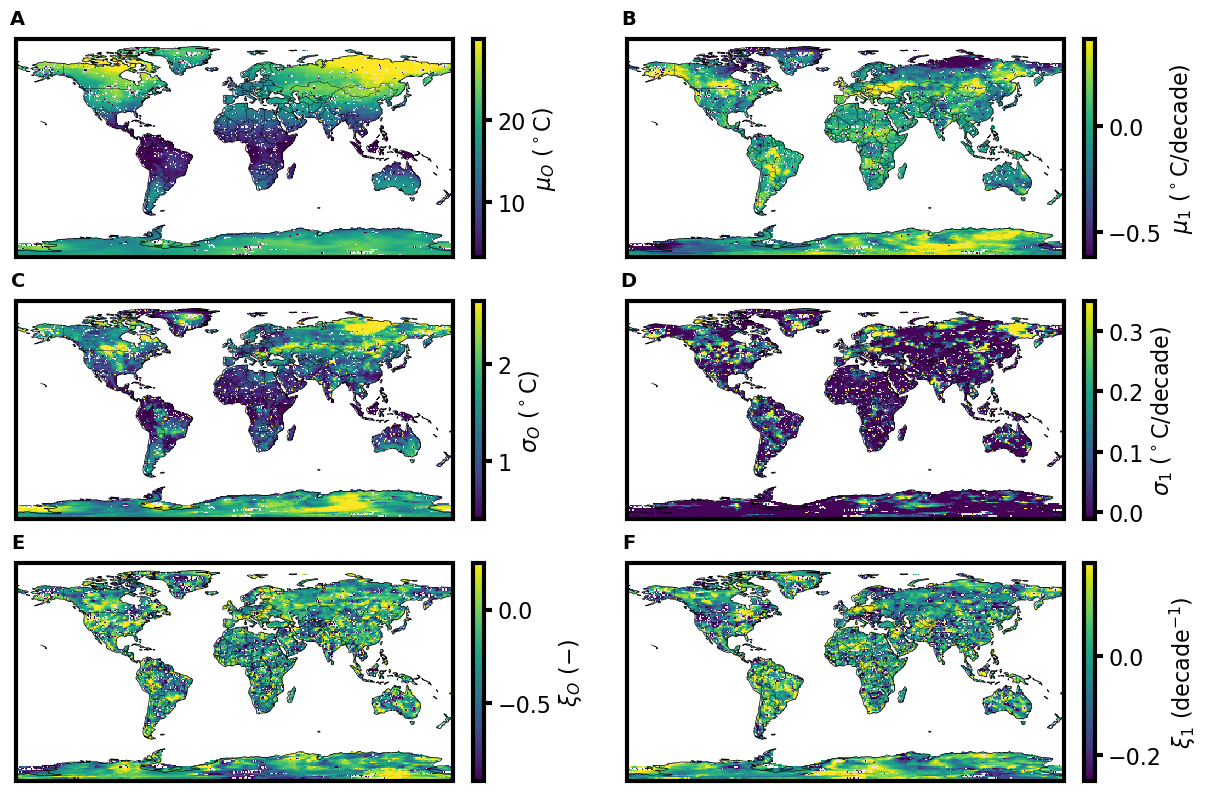

In [26]:
plot_nonstat_gev_parameters(ds_max, anom_type='anom_trend',
                            vars=[r'$\mu_O$ ($^\circ$C)', r'$\mu_1$ ($^\circ$C/decade)', 
                                  r'$\sigma_O$ ($^\circ$C)', r'$\sigma_1$ ($^\circ$C/decade)', 
                                  r'$\xi_O$ ($-$)', r'$\xi_1$ (decade$^{-1}$)'],
                                    filename_args=['t2m-anom-max-gev-nonstat-parameters-era5', 'png', 'figs'])

Figure saved!


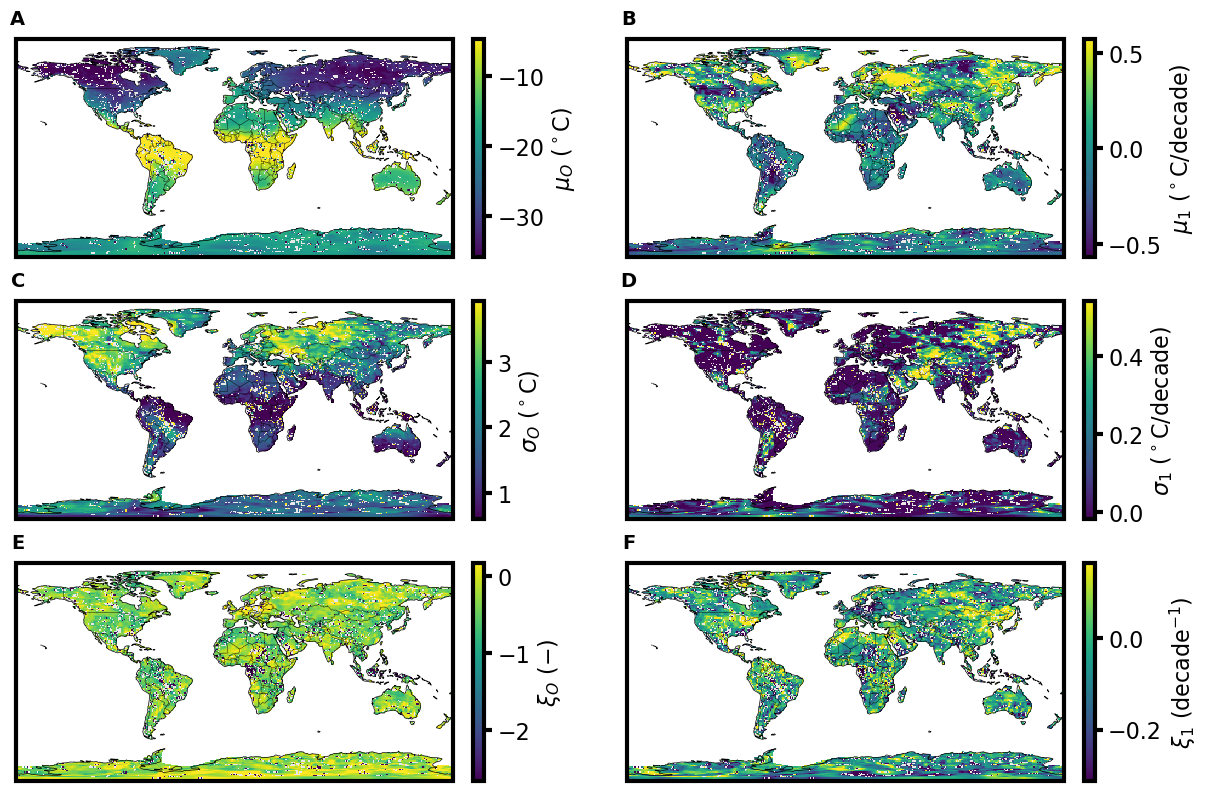

In [28]:
plot_nonstat_gev_parameters(ds_min, anom_type='anom_trend',
                            vars=[r'$\mu_O$ ($^\circ$C)', r'$\mu_1$ ($^\circ$C/decade)', 
                                  r'$\sigma_O$ ($^\circ$C)', r'$\sigma_1$ ($^\circ$C/decade)', 
                                  r'$\xi_O$ ($-$)', r'$\xi_1$ (decade$^{-1}$)'],
                                    filename_args=['t2m-anom-min-gev-nonstat-parameters-era5', 'png', 'figs'])